In [4]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

RELATIONS = ["front", "behind", "left", "right"]

TRUE_LABEL_GROUPS = {
    "front_behind": ["front", "behind"],
    "left_right": ["left", "right"]
}

def extract_camera_perspective(image_path):
    image_path = str(image_path)
    filename = os.path.basename(image_path).lower()

    m = re.search(r'_(front|behind|left|right)_of_', filename)
    if m:
        return m.group(1)
    return None

def extract_camera_perspective_comfort(image_path):
    # 处理这种 ./COMFORT/data/comfort_human_car/behind/dog__behind__cam_left/0.png
    image_path = str(image_path)
    # print("image_path:", image_path)
    parts = os.path.dirname(image_path).split("/")
    true_relation = parts[-2]
    # print("true_relation:", parts[-2])
    folder_name = parts[-1]

    segments = folder_name.split("__")   # ["dog", "behind", "cam_left"]
    cam_segment = segments[-1]           # "cam_left"
    camera_position = cam_segment.split("_")[-1]  # "left"
    # print("camera_position:", segments[-1].split("_")[-1])  # 期望: left

    camera_persective = None
    if (true_relation == "behind" and camera_position == "left") or (true_relation == "infrontof" and camera_position == "right") or (true_relation == "totheleft" and camera_position == "front") or (true_relation == "totheright" and camera_position == "back"):
        camera_persective = "right"
    elif (true_relation == "behind" and camera_position == "right") or (true_relation == "infrontof" and camera_position == "left") or (true_relation == "totheleft" and camera_position == "back") or (true_relation == "totheright" and camera_position == "front"):
        camera_persective = "left"
    elif (true_relation == "behind" and camera_position == "front") or (true_relation == "infrontof" and camera_position == "back") or (true_relation == "totheleft" and camera_position == "right") or (true_relation == "totheright" and camera_position == "left"):
        camera_persective = "behind"
    elif (true_relation == "behind" and camera_position == "back") or (true_relation == "infrontof" and camera_position == "front") or (true_relation == "totheleft" and camera_position == "left") or (true_relation == "totheright" and camera_position == "right"):
        camera_persective = "front"
    return true_relation, camera_persective

def extract_letter_to_relation(prompt):
    """
    从 mcq_prompt 中解析 A/B/C/D 分别对应哪个方向。
    要求 prompt 里包含类似：
    A. ...front...
    B. ...behind...
    C. ...left...
    D. ...right...
    顺序可打乱。
    """
    prompt = str(prompt)

    mapping = {}
    for letter in ["A", "B", "C", "D"]:
        # 提取当前选项文字，直到下一个选项字母或字符串结束
        pattern = rf"{letter}\.\s*(.*?)(?=(?:A|B|C|D)\.\s|$)"
        m = re.search(pattern, prompt, flags=re.IGNORECASE | re.DOTALL)
        if not m:
            continue

        text = m.group(1).lower()

        if "front" in text:
            mapping[letter] = "front"
        elif "behind" in text:
            mapping[letter] = "behind"
        elif "left" in text:
            mapping[letter] = "left"
        elif "right" in text:
            mapping[letter] = "right"

    return mapping


def load_and_prepare(csv_path):
    df = pd.read_csv(csv_path)

    def get_pred_relation(row):
        letter_map = extract_letter_to_relation(row["mcq_prompt"])
        pred_letter = str(row["pred_letter"]).strip()
        return letter_map.get(pred_letter, None)

    df["pred_relation"] = df.apply(get_pred_relation, axis=1)
    df["correct_relation"] = df["correct_relation"].astype(str).str.strip().str.lower()
    comfort_results = df["image_path"].apply(extract_camera_perspective_comfort)
    df["object_position"]    = comfort_results.apply(lambda x: x[0])  # true_relation
    df["object_position_under_camera_perspective"] = comfort_results.apply(lambda x: x[1])
    
    # mapping (change names)
    RELATION_MAP = {
        "infrontof": "front",
        "totheleft": "left",
        "totheright": "right",
        "behind": "behind",
        }
    df["object_position"] = comfort_results.apply(lambda x: RELATION_MAP.get(x[0], x[0]))

    return df


def analyze_percentages(df):
    rows = []

    for rel in RELATIONS:
        sub = df[df["correct_relation"] == rel]
        total = len(sub)

        if total == 0:
            rows.append({
                "correct_relation": rel,
                "total": 0,
                "correct_pct": 0.0,
                "opposite_pct": 0.0
            })
            continue

        correct = (sub["pred_letter"].astype(str).str.strip() == sub["correct_letter"].astype(str).str.strip()).sum()
        opposite = (sub["pred_letter"].astype(str).str.strip() == sub["opposite_letter"].astype(str).str.strip()).sum()

        rows.append({
            "correct_relation": rel,
            "total": total,
            "correct_pct": correct / total,
            "opposite_pct": opposite / total
        })

    return pd.DataFrame(rows)


def plot_confusion_matrix(df, title, true_labels):
    plot_df = df[
        df["correct_relation"].isin(true_labels) &
        df["pred_relation"].isin(RELATIONS)
    ].copy()

    if len(plot_df) == 0:
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.axis("off")
        ax.set_title(f"{title}\n(no data)")
        plt.show()
        return

    cm_df = pd.crosstab(
        plot_df["correct_relation"],
        plot_df["pred_relation"],
        normalize="index"
    ).reindex(index=true_labels, columns=RELATIONS, fill_value=0.0)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    im = ax.imshow(cm_df.values, cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(len(RELATIONS)))
    ax.set_xticklabels(RELATIONS)
    ax.set_yticks(range(len(true_labels)))
    ax.set_yticklabels(true_labels)

    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            val = cm_df.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center")

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.colorbar(im, ax=ax)
    plt.show()


def analyze_one_file(csv_path, title=None):
    df = load_and_prepare(csv_path)
    pct_df = analyze_percentages(df)

    if title is None:
        title = os.path.basename(csv_path)

    print(f"\n===== {title} =====")
    # display(pct_df)

    plot_confusion_matrix(
        df,
        title=f"{title} - true: front/behind",
        true_labels=TRUE_LABEL_GROUPS["front_behind"]
    )
    plot_confusion_matrix(
        df,
        title=f"{title} - true: left/right",
        true_labels=TRUE_LABEL_GROUPS["left_right"]
    )

    return df, pct_df



def plot_confusion_on_ax(df, ax, title, true_labels):
    plot_df = df[
        df["correct_relation"].isin(true_labels) &
        df["pred_relation"].isin(RELATIONS)
    ].copy()

    if len(plot_df) == 0:
        ax.axis("off")
        ax.set_title(f"{title}\n(no data)")
        return

    cm_df = pd.crosstab(
        plot_df["correct_relation"],
        plot_df["pred_relation"],
        normalize="index"
    ).reindex(index=true_labels, columns=RELATIONS, fill_value=0.0)

    im = ax.imshow(cm_df.values, cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(len(RELATIONS)))
    ax.set_xticklabels(RELATIONS)
    ax.set_yticks(range(len(true_labels)))
    ax.set_yticklabels(true_labels)

    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            val = cm_df.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center")

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")


MODEL: qwen3vl


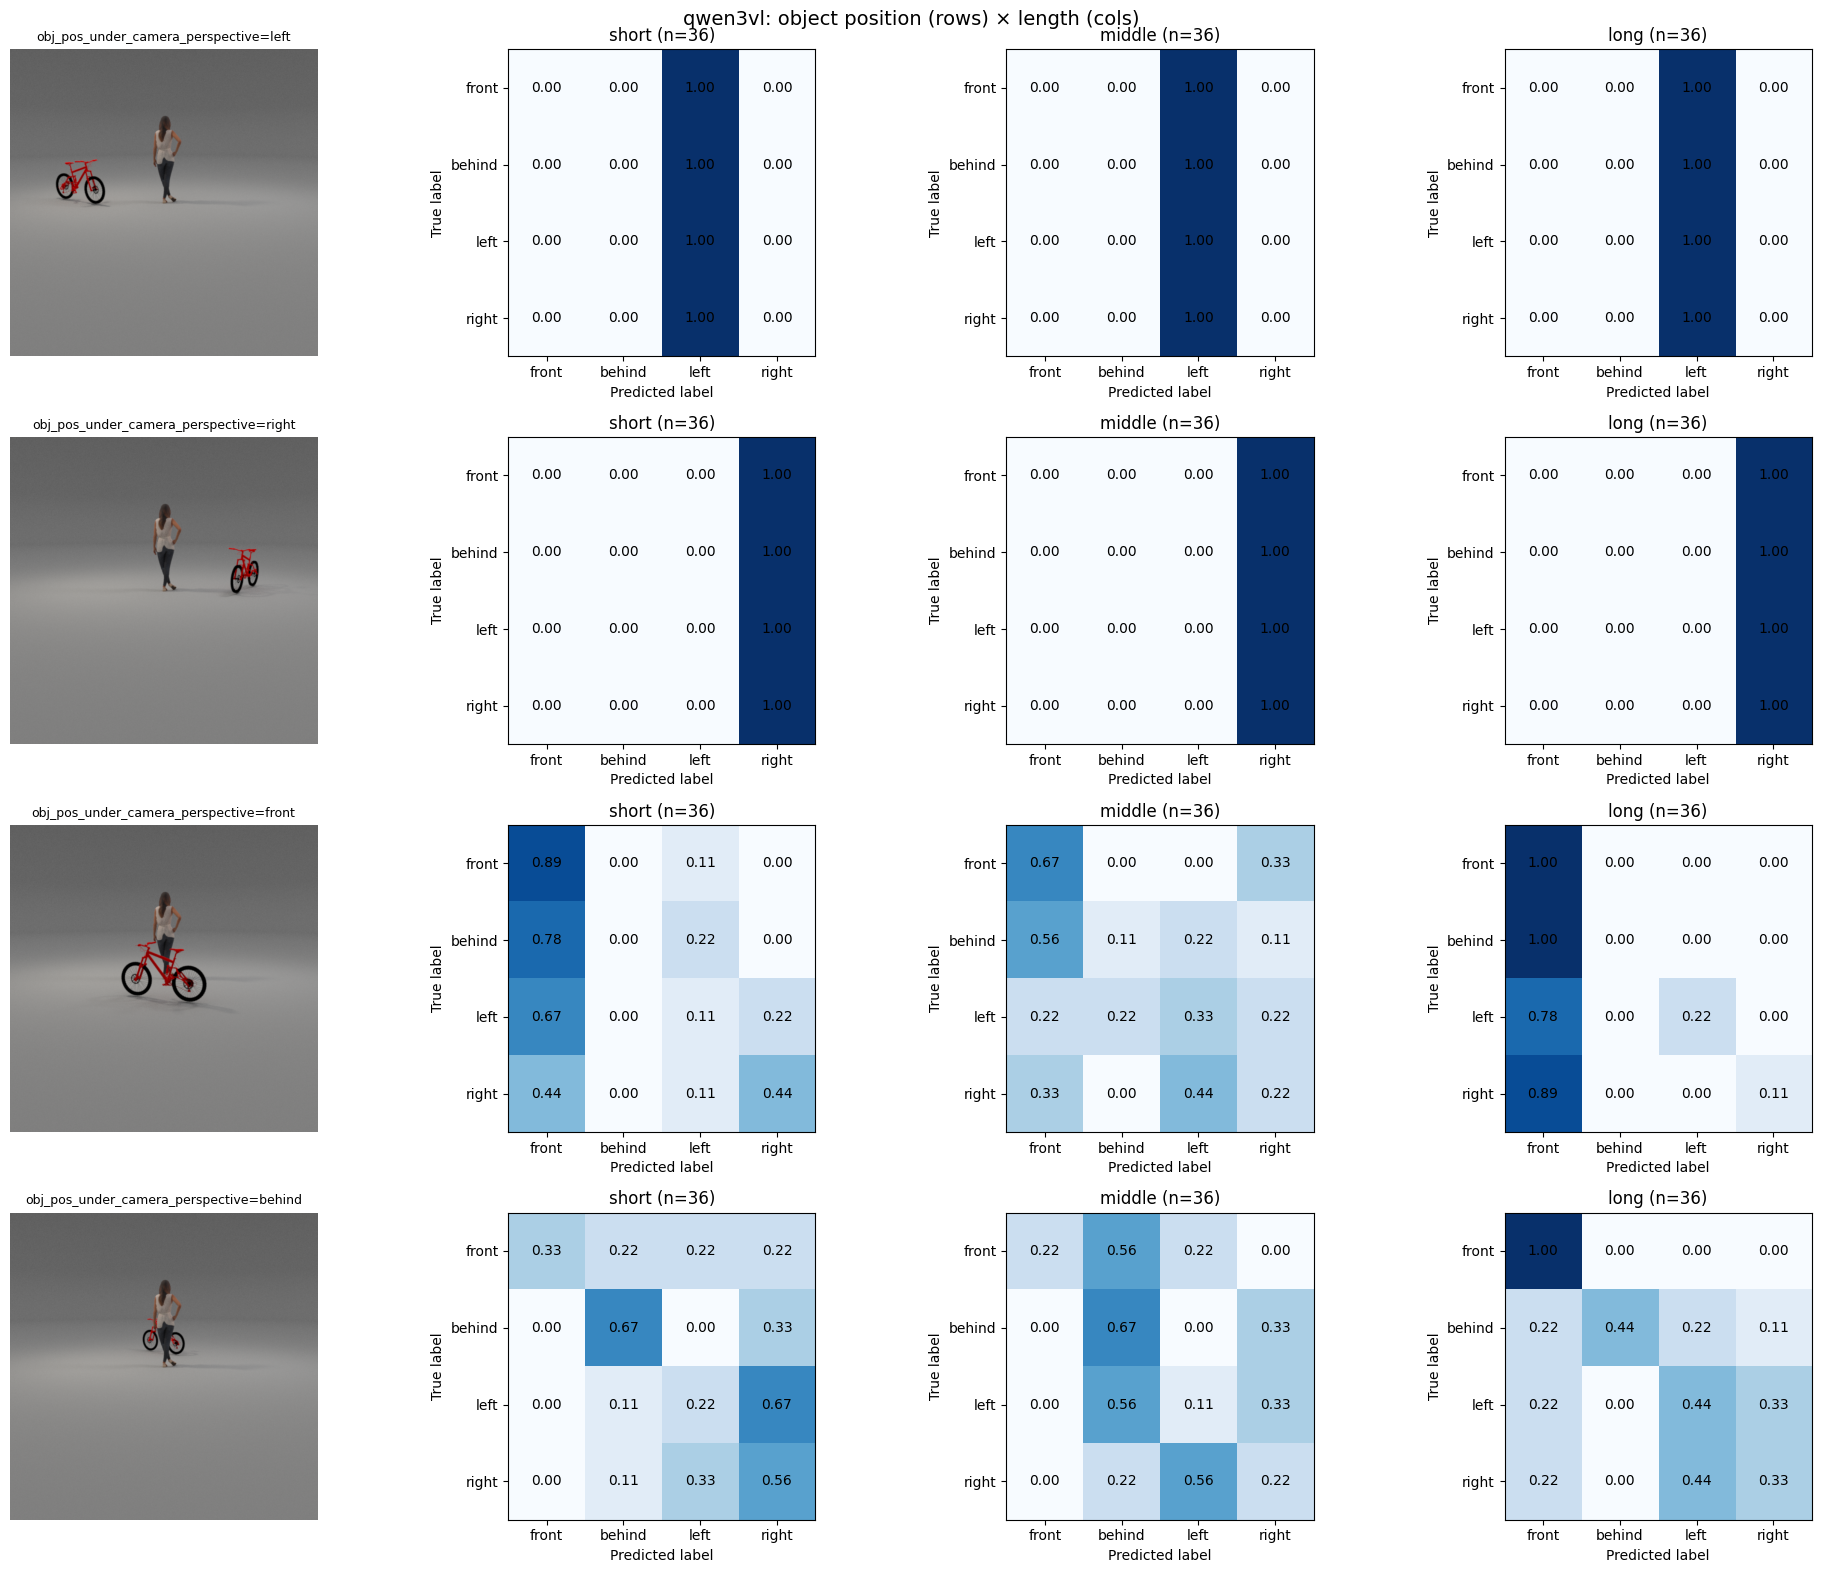

MODEL: internvl


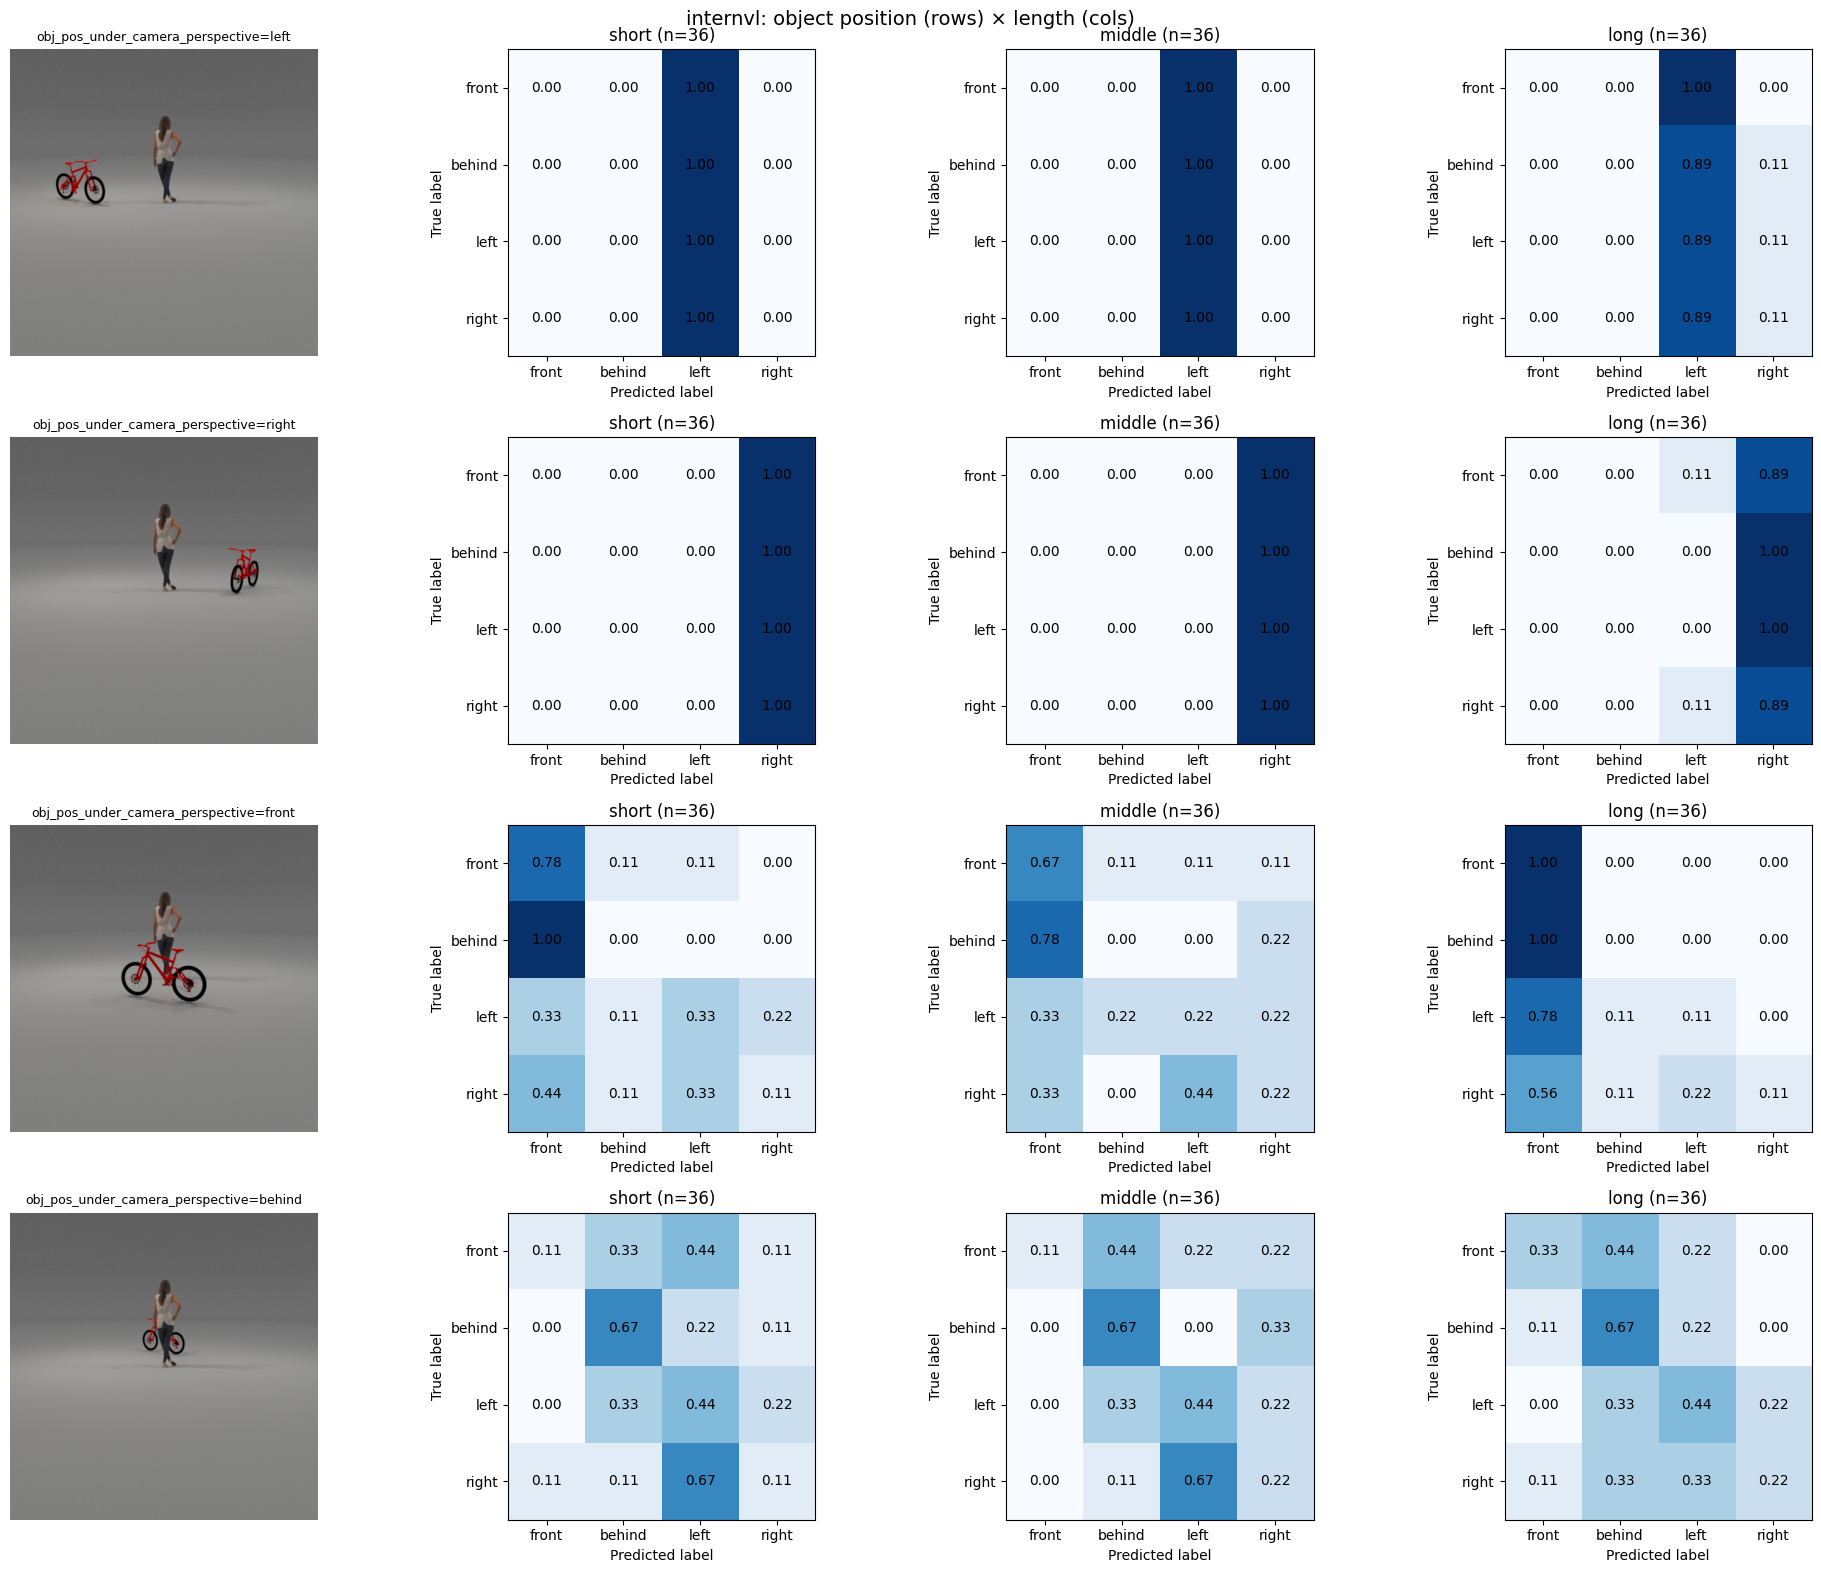

In [ ]:
EXAMPLE_IMAGES = {
    "left":   "/home/zzou/COMFORT/data/comfort_human_car/totheleft/bicycle__totheleft__cam_back/0.png",
    "right":  "/home/zzou/COMFORT/data/comfort_human_car/totheright/bicycle__totheright__cam_back/0.png",
    "front":  "/home/zzou/COMFORT/data/comfort_human_car/behind/bicycle__behind__cam_back/0.png",
    "behind": "/home/zzou/COMFORT/data/comfort_human_car/infrontof/bicycle__infrontof__cam_back/0.png",
}

from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
OBJECT_POSITIONS = ["left", "right", "front", "behind"]
# models = ["internvl", "qwen3vl", "qwen3.5", "qwen3_5vl_thinking", "gemma4"]
models = ["qwen3vl", "internvl"]

results = defaultdict(dict)


for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        dfs[length] = df
        results[model][length] = {"df": df}

    # 4行×4列：第0列示意图，第1-3列 short/middle/long
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))

    for j, obj_pos in enumerate(OBJECT_POSITIONS):

        # 第0列：示意图
        axes[j][0].imshow(plt.imread(EXAMPLE_IMAGES[obj_pos]))
        axes[j][0].axis("off")
        axes[j][0].set_title(f"obj_pos_under_camera_perspective={obj_pos}", fontsize=9)

        # 第1-3列：混淆矩阵
        for i, length in enumerate(lengths):
            ax = axes[j][i + 1]
            if length not in dfs:
                ax.axis("off")
                continue
            sub = dfs[length][dfs[length]["object_position_under_camera_perspective"] == obj_pos] # "object_position" 是按照真实物体位置来分类，"camera_perspective"是按照相机视角来分类
            plot_confusion_on_ax(
                sub,
                ax,
                title=f"{length} (n={len(sub)})",
                true_labels=RELATIONS  # 4×4，所有方向都作为 true label
            )

    fig.suptitle(f"{model}: object position (rows) × length (cols)", fontsize=14)
    plt.tight_layout()
    plt.show()

    # # 打印例子看看找问题
    # sub = dfs["short"][dfs["short"]["object_position_under_camera_perspective"] == "left"]
    # sub.to_csv(f"debug_{model}_short_left.csv", index=False)  # 保存这个子集到 CSV 文件，方便后续分析
    

MODEL: qwen3_5vl_thinking
Missing file: ./mcq_short_qwen3_5vl_thinking.csv


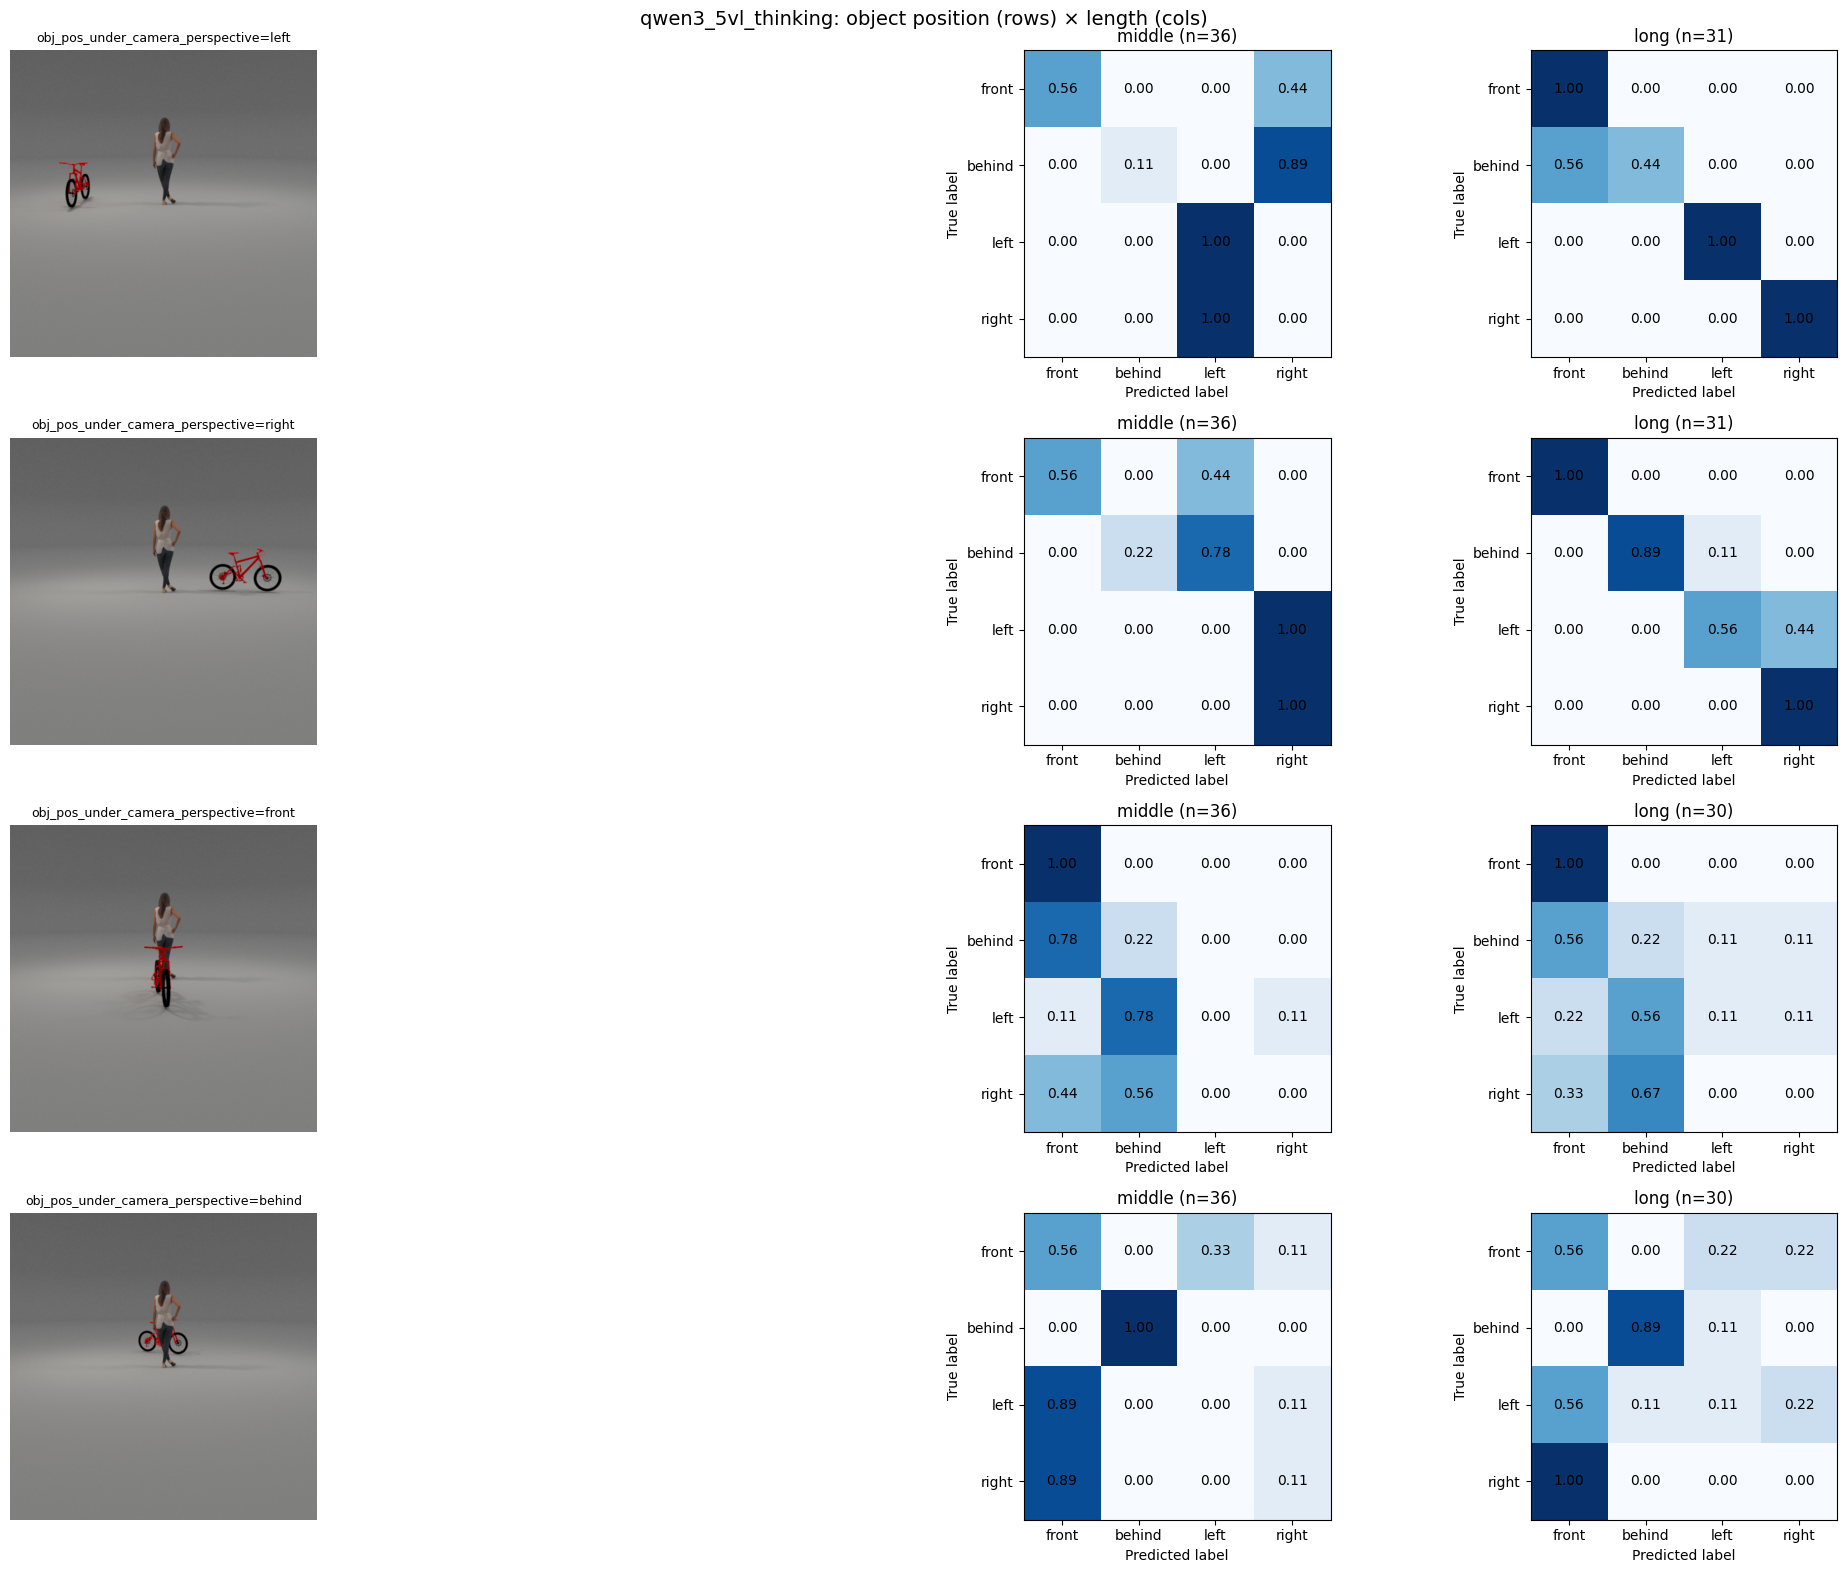

In [ ]:
EXAMPLE_IMAGES = {
    "left":   "/home/zzou/COMFORT/data/comfort_human_car/totheleft/bicycle__totheleft__cam_back/0.png",
    "right":  "/home/zzou/COMFORT/data/comfort_human_car/totheright/bicycle__totheright__cam_back/0.png",
    "front":  "/home/zzou/COMFORT/data/comfort_human_car/behind/bicycle__behind__cam_back/0.png",
    "behind": "/home/zzou/COMFORT/data/comfort_human_car/infrontof/bicycle__infrontof__cam_back/0.png",
}

from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
OBJECT_POSITIONS = ["left", "right", "front", "behind"]
# models = ["internvl", "qwen3vl", "qwen3vl_thinking", "qwen3.5", "qwen3_5vl_thinking", "gemma3"]
models = ["qwen3_5vl_thinking"]

results = defaultdict(dict)


for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        dfs[length] = df
        results[model][length] = {"df": df}

    # 4行×4列：第0列示意图，第1-3列 short/middle/long
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))

    for j, obj_pos in enumerate(OBJECT_POSITIONS):

        # 第0列：示意图
        axes[j][0].imshow(plt.imread(EXAMPLE_IMAGES[obj_pos]))
        axes[j][0].axis("off")
        axes[j][0].set_title(f"obj_pos_under_camera_perspective={obj_pos}", fontsize=9)

        # 第1-3列：混淆矩阵
        for i, length in enumerate(lengths):
            ax = axes[j][i + 1]
            if length not in dfs:
                ax.axis("off")
                continue
            sub = dfs[length][dfs[length]["object_position_under_camera_perspective"] == obj_pos] # "object_position" 是按照真实物体位置来分类，"camera_perspective"是按照相机视角来分类
            plot_confusion_on_ax(
                sub,
                ax,
                title=f"{length} (n={len(sub)})",
                true_labels=RELATIONS  # 4×4，所有方向都作为 true label
            )

    fig.suptitle(f"{model}: object position (rows) × length (cols)", fontsize=14)
    plt.tight_layout()
    plt.show()

In [3]:
df_raw = pd.read_csv("./mcq_middle_qwen3_5vl_thinking.csv")
print(df_raw.shape[0])
# print(df_raw["image_path"].iloc[0])
# test_path = df_raw["image_path"].iloc[0]
# print(extract_camera_perspective_comfort(test_path))

144


### internvl

MODEL: internvl
Missing file: ./mcq_short_internvl.csv
Missing file: ./mcq_middle_internvl.csv
Missing file: ./mcq_long_internvl.csv


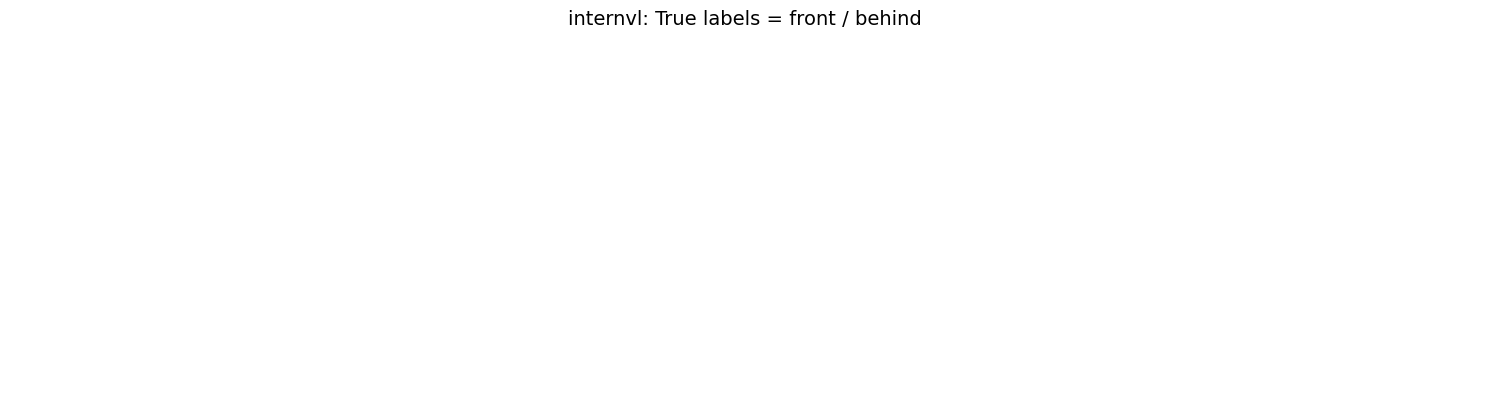

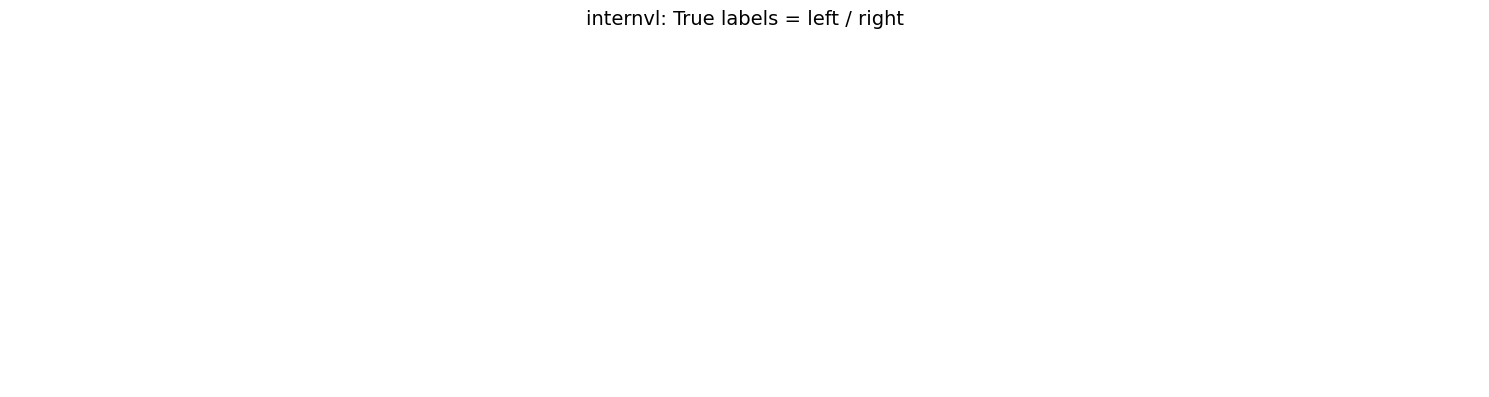

In [2]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["internvl"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }

    # Figure 1: true label = front / behind, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
    fig.suptitle(f"{model}: True labels = front / behind", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Figure 2: true label = left / right, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )
    fig.suptitle(f"{model}: True labels = left / right", fontsize=14)
    plt.tight_layout()
    plt.show()

### qwen3-vl

MODEL: qwen3vl


,correct_relation,total,correct_pct,opposite_pct
0,front,36,0.222222,0.083333
1,behind,36,0.194444,0.194444
2,left,36,0.472222,0.472222
3,right,36,0.388889,0.388889


,correct_relation,total,correct_pct,opposite_pct
0,front,36,0.250000,0.083333
1,behind,36,0.277778,0.166667
2,left,36,0.416667,0.388889
3,right,36,0.388889,0.388889


,correct_relation,total,correct_pct,opposite_pct
0,front,36,0.388889,0.000000
1,behind,36,0.027778,0.305556
2,left,36,0.333333,0.361111
3,right,36,0.333333,0.388889


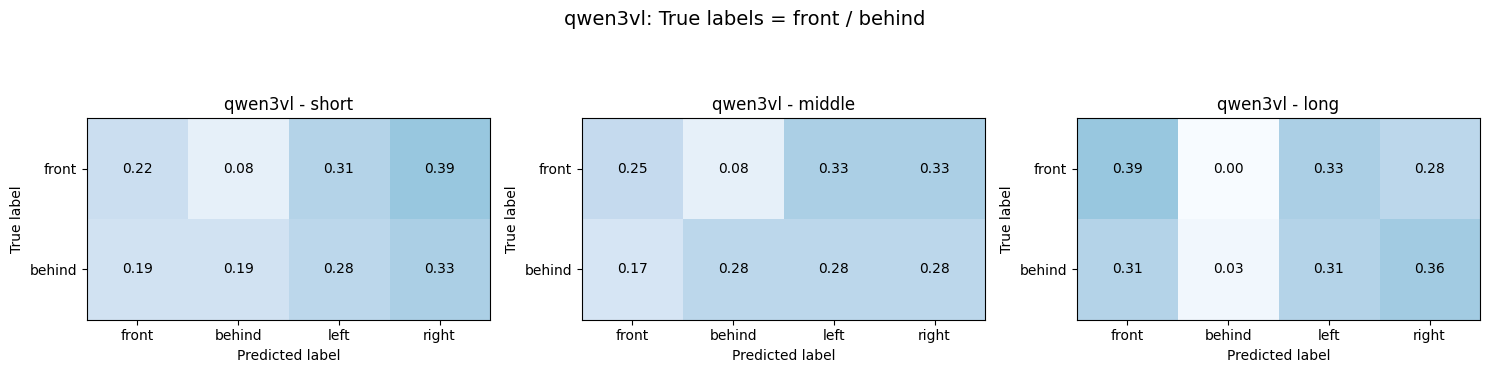

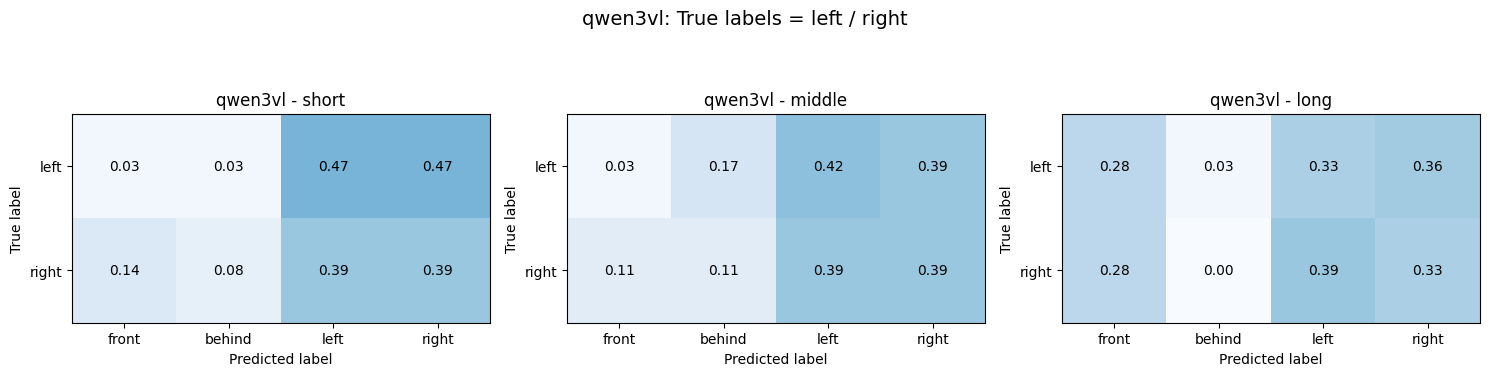

In [3]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["qwen3vl"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }

    # Figure 1: true label = front / behind, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
    fig.suptitle(f"{model}: True labels = front / behind", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Figure 2: true label = left / right, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )
    fig.suptitle(f"{model}: True labels = left / right", fontsize=14)
    plt.tight_layout()
    plt.show()

### qwen3-vl-thinking

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["qwen3vl_thinking"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }

    # Figure 1: true label = front / behind, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
    fig.suptitle(f"{model}: True labels = front / behind", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Figure 2: true label = left / right, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )
    fig.suptitle(f"{model}: True labels = left / right", fontsize=14)
    plt.tight_layout()
    plt.show()

### Qwen3.5

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["qwen3.5"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }

    # Figure 1: true label = front / behind, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
    fig.suptitle(f"{model}: True labels = front / behind", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Figure 2: true label = left / right, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )
    fig.suptitle(f"{model}: True labels = left / right", fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short",  "long"]
models = ["qwen3_5vl_thinking"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }

    # Figure 1: true label = front / behind, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
    fig.suptitle(f"{model}: True labels = front / behind", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Figure 2: true label = left / right, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )
    fig.suptitle(f"{model}: True labels = left / right", fontsize=14)
    plt.tight_layout()
    plt.show()

### Gemma3-12B

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt

base_dir = "./"
lengths = ["short", "middle", "long"]
models = ["gemma3"]

results = defaultdict(dict)

for model in models:

    print(f"MODEL: {model}")

    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"Missing file: {csv_path}")
            continue

        df = load_and_prepare(csv_path)
        pct_df = analyze_percentages(df)

        display(pct_df)
        dfs[length] = df
        results[model][length] = {
            "df": df,
            "percentages": pct_df
        }

    # Figure 1: true label = front / behind, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
    fig.suptitle(f"{model}: True labels = front / behind", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Figure 2: true label = left / right, predicted = all 4
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length],
            axes[i],
            title=f"{model} - {length}",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )
    fig.suptitle(f"{model}: True labels = left / right", fontsize=14)
    plt.tight_layout()
    plt.show()